# Document Layout Detection: YOLO vs RT-DETR

## Data Preparation

### Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = "/content/drive/MyDrive/doclayout-det"

Mounted at /content/drive


In [2]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.2 MB/s eta 0:00:0000:01


### Unzip Dataset

In [3]:
import zipfile
import os

data_path = f'{DRIVE_PATH}/data_multi_cat.zip'

# Define the destination directory (current working directory)
destination_dir = '.'
# name of the folder that will be created after unzipping
unzipped_folder_name = '.data'
# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Unzip the file
print(f"Unzipping {data_path} to {destination_dir}...")
with zipfile.ZipFile(data_path, 'r') as zip_ref:
    original_folder_name = zip_ref.namelist()[0].split('/')[0]
    zip_ref.extractall(destination_dir)
print("Unzipping complete!")

original_folder_path = os.path.join(destination_dir, original_folder_name)
target_folder_path = os.path.join(destination_dir, unzipped_folder_name)
os.rename(original_folder_path, target_folder_path)

Unzipping /content/drive/MyDrive/doclayout-det/data_multi_cat.zip to ....
Unzipping complete!


In [4]:
folders_to_rename = ['labels_coco_multi_cat', 'images_multi_cat']

for folder_name in folders_to_rename:
    old_subfolder_path = os.path.join(target_folder_path, folder_name)
    if os.path.exists(old_subfolder_path):
        new_folder_name = folder_name.replace('_multi_cat', '')
        new_subfolder_path = os.path.join(target_folder_path, new_folder_name)
        os.rename(old_subfolder_path, new_subfolder_path)
        print(f"Renamed: {folder_name} -> {new_folder_name}")
    else:
        print(f"Warning: Folder {folder_name} not found in {target_folder_path}")

Renamed: labels_coco_multi_cat -> labels_coco
Renamed: images_multi_cat -> images


### Validate Data Extraction

In [5]:
# printing length of folder .data/images/train
import os
num_train_images = len(os.listdir(".data/images/train"))
print(f"Number of training images: {num_train_images}")

Number of training images: 9000


In [6]:
import os
# printing length of folder .data/images/val
num_val_images = len(os.listdir(".data/images/val"))
print(f"Number of validation images: {num_val_images}")

Number of validation images: 2832


### Convert COCO to YOLO Format

In [10]:
from ultralytics.data.converter import convert_coco
import shutil
from pathlib import Path

convert_coco(
    labels_dir=".data/labels_coco/",
    save_dir=".data/converted",
    cls91to80=False,
)

converted_dir = Path(".data/converted/")
dataset_dir = Path(".data")

split_mapping = {
    "labels_coco_train": "train",
    "labels_coco_val": "val",
    "labels_coco_test": "test"
}

for json_name, yolo_split in split_mapping.items():
    src = converted_dir / "labels" / json_name
    dst = dataset_dir / "labels" / yolo_split

    if src.exists():
        dst.mkdir(parents=True, exist_ok=True)
        print(f"Moving labels from {src} to {dst}...")

        files_to_move = list(src.glob("*.txt"))
        for f in files_to_move:
            shutil.move(str(f), str(dst / f.name))
    else:
        print(f"Note: Folder {src} not found.")

if converted_dir.exists():
    shutil.rmtree(converted_dir)
    print("Successfully cleaned up temporary conversion folder.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Annotations /content/.data/labels_coco/labels_coco_test.json: 100% ━━━━━━━━━━━━ 2350/2350 3.7Kit/s 0.6s0.0s
Annotations /content/.data/labels_coco/labels_coco_train.json: 100% ━━━━━━━━━━━━ 8953/8953 3.7Kit/s 2.4s0.0s
Annotations /content/.data/labels_coco/labels_coco_val.json: 100% ━━━━━━━━━━━━ 2824/2824 2.7Kit/s 1.0s0.0s
COCO data converted successfully.
Results saved to /content/.data/converted
Moving labels from .data/converted/labels/labels_coco_train to .data/labels/train...
Moving labels from .data/converted/labels/labels_coco_val to .data/labels/val...
Moving labels from .data/converted/labels/labels_coco_test to .data/labels/test...
Successfully cleaned up temporary conver

In [11]:
import json
from pathlib import Path

import yaml

with open(".data/labels_coco/labels_coco_train.json") as f:
    coco = json.load(f)

categories = sorted(coco["categories"], key=lambda x: x["id"])
names = {cat["id"] - 1: cat["name"] for cat in categories}

dataset = {
    "path": str(Path(".data").resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": names,
}

with open(".data/dataset.yaml", "w") as f:
    yaml.dump(dataset, f, default_flow_style=False)

## Training YOLO

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26l.pt")

results = model.train(
    data=".data/dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    workers=4,
    project="doclaynet_vergleich",
    name="/content/drive/MyDrive/doclayout-det/yolo26l-multi_cat"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26l-multi_cat-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

In [ ]:
print("\n--- TESTRUN EVALUATION METRICS ---")
print(f"mAP50:    {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")


--- TESTRUN EVALUATION METRICS ---
mAP50:    0.8520
mAP50-95: 0.6861


## Training RT-DETR

In [ ]:
from ultralytics import RTDETR

rtdetr = RTDETR("rtdetr-l.pt")

results = rtdetr.train(
    data=".data/dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    workers=4,
    project="doclaynet_vergleich",
    name="/content/drive/MyDrive/doclayout-det/rt_detr_l-multi_cat"
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rt_detr_l-multi_cat, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      13.9G     0.6541      1.222     0.3197        144        640: 100% ━━━━━━━━━━━━ 563/563 1.2s/it 11:06
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.1it/s 1:18
                   all       2832      38544      0.768      0.656      0.691       0.52

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      13.9G     0.3065     0.4743    0.07535        124        640: 100% ━━━━━━━━━━━━ 563/563 1.2s/it 10:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.2it/s 1:13
                   all       2832      38544      0.835      0.696      0.781      0.591

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

       8/10      13.5G     0.2067     0.3275    0.04536        112        640: 100% ━━━━━━━━━━━━ 563/563 1.1s/it 10:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.3it/s 1:09
                   all       2832      38544      0.864      0.808      0.871      0.705

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      12.4G     0.2002     0.3164    0.04376         93        640: 100% ━━━━━━━━━━━━ 563/563 1.1s/it 10:32
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.3it/s 1:09
                   all       2832      38544      0.882      0.795      0.872       0.71

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      13.6G     0.1912     0.3037    0.04165         86        640: 100% ━━━━━━━━━━━━ 563/563 1.1s/it 10:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.2it/s 1:13
                   all       2832      38544      0.877      0.811       0.88      0.723

10 epochs completed in 1.996 hours.
Optimizer stripped from /content/drive/MyDrive/doclayout-det/rt_detr_l-multi_cat/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/MyDrive/doclayout-det/rt_detr_l-multi_cat/weights/best.pt, 66.3MB

Validating /content/drive/MyDrive/doclayout-det/rt_detr_l-multi_cat/weights/best.pt...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,006,345 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 89/89 1.1it/s 1:19
                   all       2832      3

## Evaluation

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO, RTDETR

YOLO_WEIGHTS   = f"{DRIVE_PATH}/yolo26l-multi_cat-6/weights/best.pt"
RTDETR_WEIGHTS = f"{DRIVE_PATH}/rt_detr_l-multi_cat/weights/best.pt"

SPEED_TEST = False
TRIALS     = 10
MODE       = "multi_cat"

VAL_KWARGS = dict(
    data="/content/.data/dataset.yaml",
    split="test",
    imgsz=640,
    batch=1,
    workers=2,
    plots=False,
    verbose=False,
)

def run_speed_benchmark(model, device, use_gpu, trials):
    print("Warming up pipeline...")
    model.val(device=device, **VAL_KWARGS)
    if use_gpu:
        torch.cuda.synchronize()

    preprocess_runs, inference_runs, postprocess_runs = [], [], []

    for i in range(trials):
        print(f"  Speed Trial {i+1}/{trials}...")
        if use_gpu:
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        m = model.val(device=device, **VAL_KWARGS)

        if use_gpu:
            torch.cuda.synchronize()

        preprocess_runs.append(m.speed["preprocess"])
        inference_runs.append(m.speed["inference"])
        postprocess_runs.append(m.speed["postprocess"])

    mean_pre,  std_pre  = np.mean(preprocess_runs),  np.std(preprocess_runs)
    mean_inf,  std_inf  = np.mean(inference_runs),   np.std(inference_runs)
    mean_post, std_post = np.mean(postprocess_runs), np.std(postprocess_runs)
    total_latency = mean_pre + mean_inf + mean_post

    speed_dict = {"Trials_Count": trials}
    for idx in range(trials):
        speed_dict[f"Trial_{idx+1}_Pre (ms)"]  = round(preprocess_runs[idx], 2)
        speed_dict[f"Trial_{idx+1}_Inf (ms)"]  = round(inference_runs[idx],  2)
        speed_dict[f"Trial_{idx+1}_Post (ms)"] = round(postprocess_runs[idx], 2)

    speed_dict.update({
        "Mean_Pre (ms)":      round(mean_pre,      2),
        "Std_Pre (ms)":       round(std_pre,       2),
        "Mean_Inf (ms)":      round(mean_inf,      2),
        "Std_Inf (ms)":       round(std_inf,       2),
        "Mean_Post (ms)":     round(mean_post,     2),
        "Std_Post (ms)":      round(std_post,      2),
        "Total_Latency (ms)": round(total_latency, 2),
        "Throughput (FPS)":   round(1000 / total_latency, 1),
    })
    return speed_dict


def evaluate_model(model_path, model_type="YOLO", speed_test=True, trials=10):
    print(f"\n{'='*40}")
    print(f"Evaluating {model_type} | speed_test={speed_test}")
    print(f"{'='*40}")

    if not os.path.exists(model_path):
        print(f"Error: Weights not found at {model_path}!")
        return None, None, None, None

    use_gpu  = torch.cuda.is_available()
    device   = 0 if use_gpu else "cpu"
    gpu_name = torch.cuda.get_device_name(device) if use_gpu else "CPU"

    if model_type == "YOLO":
        model = YOLO(model_path)
    elif model_type == "RT-DETR":
        model = RTDETR(model_path)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Performance metrics (single run)
    print("Running performance evaluation...")
    metrics = model.val(device=device, **VAL_KWARGS)
    if use_gpu:
        torch.cuda.synchronize()

    perf_dict_overall = {
        "Model_Type": model_type,
        "Hardware":   gpu_name,
        "mAP50":      round(metrics.box.map50, 4),
        "mAP50-95":   round(metrics.box.map,   4),
        "Precision":  round(metrics.box.mp,    4),
        "Recall":     round(metrics.box.mr,    4),
    }

    class_names = metrics.names
    perf_rows_per_class = []
    for class_id, class_name in class_names.items():
        ap50    = metrics.box.ap50[class_id] if class_id < len(metrics.box.ap50) else 0
        ap50_95 = metrics.box.ap[class_id]   if class_id < len(metrics.box.ap)   else 0
        perf_rows_per_class.append({
            "Model_Type": model_type,
            "Class_ID":   class_id,
            "Class_Name": class_name,
            "mAP50":      round(ap50,    4),
            "mAP50-95":   round(ap50_95, 4),
        })

    # Speed benchmark
    speed_dict = None
    if speed_test:
        print(f"\nRunning speed benchmark ({trials} trials)...")
        speed_dict = run_speed_benchmark(model, device, use_gpu, trials)
        speed_dict = {"Model_Type": model_type, "Hardware": gpu_name, **speed_dict}

    return perf_dict_overall, perf_rows_per_class, speed_dict, metrics


perf_overall_results = []
perf_class_results   = []
speed_results        = []

p_overall, p_class, s_res, yolo_metrics = evaluate_model(
    YOLO_WEIGHTS, model_type="YOLO", speed_test=SPEED_TEST, trials=TRIALS
)
if p_overall:
    perf_overall_results.append(p_overall)
if p_class:
    perf_class_results.extend(p_class)
if s_res:
    speed_results.append(s_res)

p_overall, p_class, s_res, rtdetr_metrics = evaluate_model(
    RTDETR_WEIGHTS, model_type="RT-DETR", speed_test=SPEED_TEST, trials=TRIALS
)
if p_overall:
    perf_overall_results.append(p_overall)
if p_class:
    perf_class_results.extend(p_class)
if s_res:
    speed_results.append(s_res)

df_performance_overall = pd.DataFrame(perf_overall_results)
df_performance_class   = pd.DataFrame(perf_class_results)

df_performance_overall.to_csv(f"{DRIVE_PATH}/performance_overall_{MODE}.csv", index=False)
df_performance_class.to_csv(f"{DRIVE_PATH}/performance_per_class_{MODE}.csv", index=False)

if speed_results:
    df_speed = pd.DataFrame(speed_results)
    df_speed.to_csv(f"{DRIVE_PATH}/speed_{MODE}.csv", index=False)


Evaluating YOLO | speed_test=False
Running performance evaluation...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26l summary (fused): 190 layers, 24,754,221 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3187.9±740.7 MB/s, size: 431.7 KB)
val: Scanning /content/.data/labels/test... 2350 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2352/2352 915.0it/s 2.6s0.1s
val: New cache created: /content/.data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2352/2352 24.1it/s 1:380.1sss
                   all       2352      30376      0.814      0.718      0.802      0.626
Speed: 1.3ms preprocess, 33.3ms inference, 0.0ms loss, 0.3ms postprocess per image

Evaluating RT-DETR | speed_test=False
Running performance evaluation...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 l

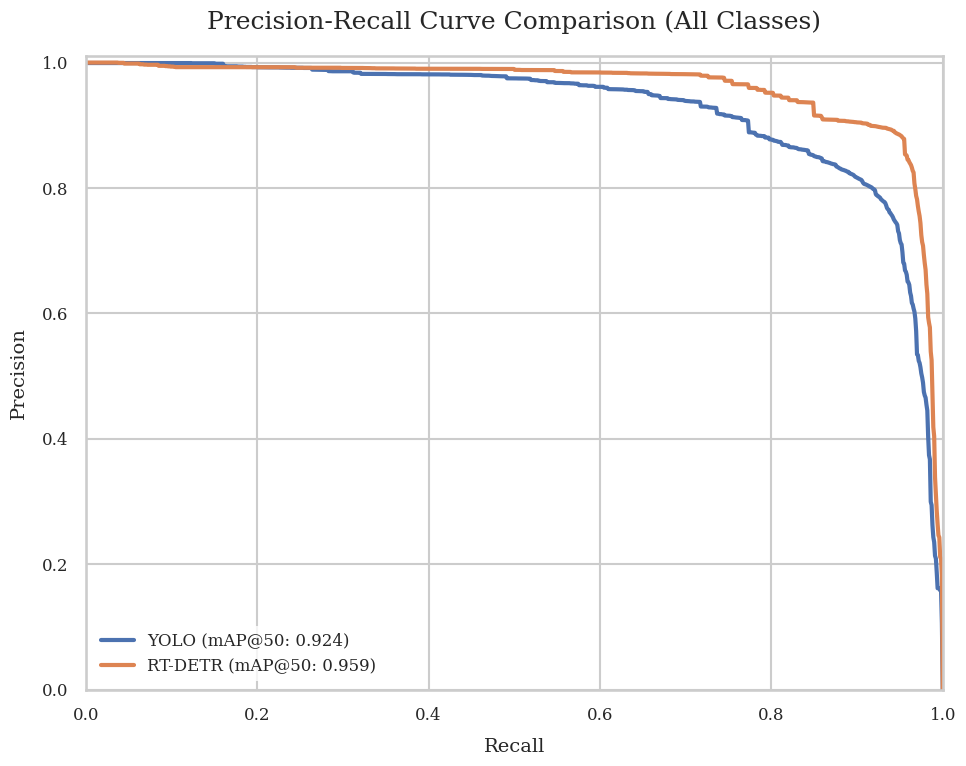

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_combined_pr_curve(yolo_metrics, rtdetr_metrics, output_filename="combined_pr_curve.png"):
    # extract data for YOLO
    pr_curve_yolo = yolo_metrics.curves_results[0]
    recall_yolo = pr_curve_yolo[0]            # x-Werte (Recall)
    precision_matrix_yolo = pr_curve_yolo[1]  # 2D-Array [Klassen, Punkte]
    
    # calculate mean precision across all classes for YOLO
    mean_precision_yolo = np.mean(precision_matrix_yolo, axis=0)
    
    # Get the overall mAP@50 for YOLO from the results_dict for the legend
    map50_yolo = yolo_metrics.results_dict.get('metrics/mAP50(B)', 0.0)

    # extract data for RT-DETR
    pr_curve_rtdetr = rtdetr_metrics.curves_results[0]
    recall_rtdetr = pr_curve_rtdetr[0]
    precision_matrix_rtdetr = pr_curve_rtdetr[1]
    
    mean_precision_rtdetr = np.mean(precision_matrix_rtdetr, axis=0)
    map50_rtdetr = rtdetr_metrics.results_dict.get('metrics/mAP50(B)', 0.0)

    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"]
    })
    sns.set_theme(style="whitegrid", context="talk", rc={"font.family": "serif"}) 
    plt.figure(figsize=(10, 8))

    plt.plot(
        recall_yolo, 
        mean_precision_yolo, 
        linewidth=3, 
        label=f"YOLO26 (mAP@50: {map50_yolo:.3f})"
    )

    plt.plot(
        recall_rtdetr, 
        mean_precision_rtdetr, 
        linewidth=3, 
        label=f"RT-DETR (mAP@50: {map50_rtdetr:.3f})"
    )

    plt.title("Precision-Recall Curve Comparison (All Classes)", fontsize=18, pad=20)
    plt.xlabel("Recall", fontsize=14, labelpad=10)
    plt.ylabel("Precision", fontsize=14, labelpad=10)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.01])

    plt.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="none", fontsize=12)
    
    plt.tight_layout()
    
    plt.savefig(output_filename, dpi=300)
    plt.show()

plot_combined_pr_curve(yolo_metrics, rtdetr_metrics)

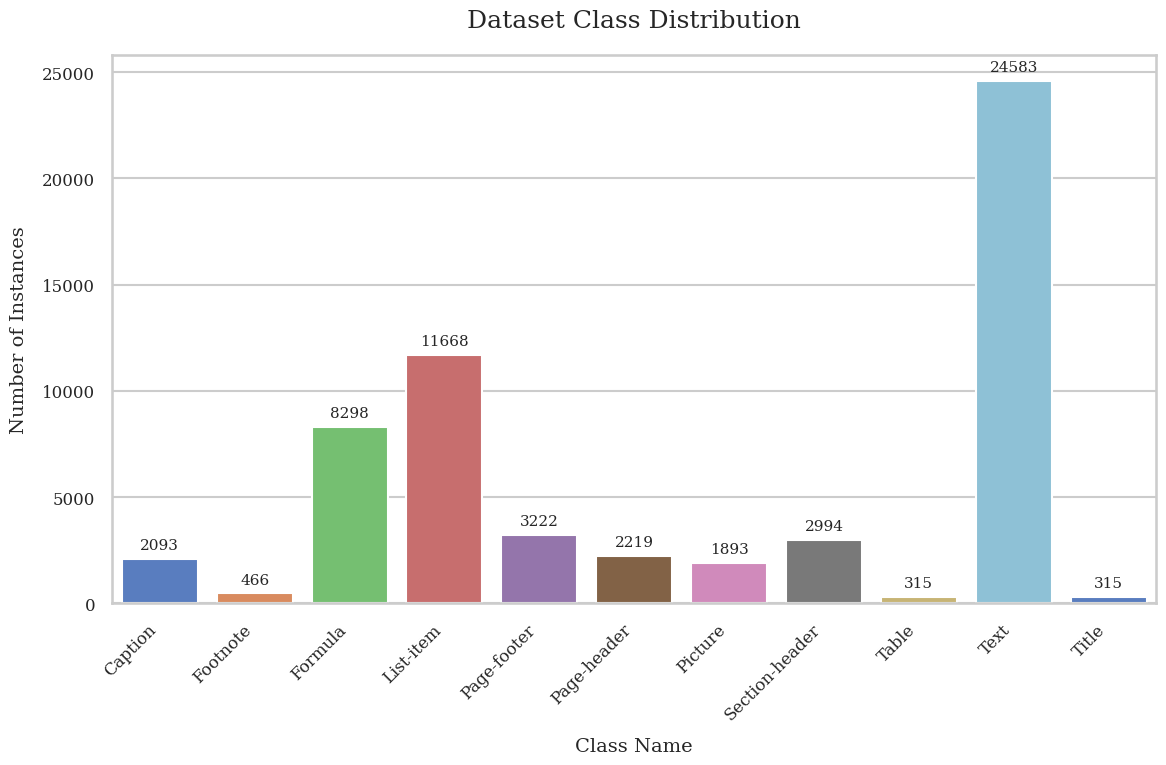

[INFO] Plot erfolgreich gespeichert unter: label_distribution.png


In [ ]:
import os
import glob
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dataset_distribution(data_yaml_path, labels_dir_path, output_filename="label_distribution.png"):
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"]
    })

    # load class names from dataset.yaml
    with open(data_yaml_path, 'r', encoding='utf-8') as f:
        data_config = yaml.safe_load(f)
    
    class_names = data_config.get('names', {})
    class_counts = {int(k): 0 for k in class_names.keys()} if isinstance(class_names, dict) else {i: 0 for i in range(len(class_names))}
    
    label_files = glob.glob(os.path.join(labels_dir_path, "*.txt"))
    
    if not label_files:
        print(f"Error: Keine .txt Dateien im Ordner {labels_dir_path} gefunden!")
        return

    for file_path in label_files:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    if class_id in class_counts:
                        class_counts[class_id] += 1

    df_data = []
    for class_id, count in class_counts.items():
        name = class_names[class_id]
        df_data.append({"Class": name, "Instances": count})
        
    df = pd.DataFrame(df_data)
    
    sns.set_theme(style="whitegrid", context="talk", rc={"font.family": "serif"}) 
    plt.figure(figsize=(12, 8))
    
    ax = sns.barplot(
        x="Class", 
        y="Instances", 
        data=df, 
        palette="muted", 
        hue="Class",      
        legend=False
    )
    
    plt.title("Dataset Class Distribution", fontsize=18, pad=20)
    plt.xlabel("Class Name", fontsize=14, labelpad=10)
    plt.ylabel("Number of Instances", fontsize=14, labelpad=10)
    
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    
    # display the count on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='bottom', 
                fontsize=11, 
                xytext=(0, 5), 
                textcoords='offset points'
            )
            
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"[INFO] Plot erfolgreich gespeichert unter: {output_filename}")

DATA_YAML = "/content/.data/dataset.yaml"
LABELS_DIR = "/content/.data/labels/train"  

plot_dataset_distribution(DATA_YAML, LABELS_DIR)

In [ ]:
import os
import time
import torch
import numpy as np
import pandas as pd
from ultralytics import YOLO, RTDETR

YOLO_WEIGHTS = r"/content/drive/MyDrive/doclayout-det/yolo26l/weights/best.pt"
RTDETR_WEIGHTS = r"/content/drive/MyDrive/doclayout-det/rt_detr_l-4/weights/best.pt"

def export_and_evaluate(model_path, model_type="YOLO", trials=10):
    print(f"\n{'='*50}\nProcessing: {model_type} ({model_path})\n{'='*50}")

    if not os.path.exists(model_path):
        print(f"Error: Weights not found at {model_path}!")
        return None, None

    # 1. Modell im Entwicklungsmodus (.pt) laden
    if model_type == "YOLO":
        model = YOLO(model_path)
    elif model_type == "RT-DETR":
        model = RTDETR(model_path)

    # 2. TensorRT-Export (.engine) generieren
    # Hinweis: half=True aktiviert FP16-Präzision, was auf der T4 GPU extrem beschleunigt!
    engine_path = model_path.replace(".pt", ".engine")
    if not os.path.exists(engine_path):
        print(f"Exporting {model_type} to TensorRT (.engine format)... This can take a few minutes.")
        model.export(format="engine", imgsz=640, half=True, device=0)
    else:
        print(f"Optimized TensorRT engine already exists at: {engine_path}")

    # 3. Das fertig optimierte Hardware-Modell laden
    print(f"Loading TensorRT Engine for speed benchmarks...")
    if model_type == "YOLO":
        optimized_model = YOLO(engine_path)
    elif model_type == "RT-DETR":
        optimized_model = RTDETR(engine_path)

    # Hardware-Warmup mit dem optimierten Modell
    print("Warming up hardware layers with TensorRT engine...")
    dummy_input = torch.zeros((1, 3, 640, 640)).to(0)
    for _ in range(30):
        _ = optimized_model.model(dummy_input) if hasattr(optimized_model, 'model') else optimized_model(dummy_input)
    torch.cuda.synchronize()

    # Data collection
    preprocess_runs = []
    inference_runs = []
    postprocess_runs = []
    final_metrics = None

    # Multi-trial Speed Loop mit der Engine
    for i in range(trials):
        print(f"Executing TensorRT Trial {i+1}/{trials}...")
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        metrics = optimized_model.val(
            data="/content/.data/dataset.yaml",
            split="test",
            imgsz=640,
            batch=1,       # Latenz-Standard (Echtzeit-Szenario)
            workers=2,
            device=0,
            plots=False,
            verbose=False
        )
        
        if i == 0:
            final_metrics = metrics
            
        preprocess_runs.append(metrics.speed['preprocess'])
        inference_runs.append(metrics.speed['inference'])
        postprocess_runs.append(metrics.speed['postprocess'])

    # Ergebnisse zusammenfassen
    gpu_name = torch.cuda.get_device_name(0)
    mean_pre, std_pre = np.mean(preprocess_runs), np.std(preprocess_runs)
    mean_inf, std_inf = np.mean(inference_runs), np.std(inference_runs)
    mean_post, std_post = np.mean(postprocess_runs), np.std(postprocess_runs)
    total_latency = mean_pre + mean_inf + mean_post

    perf_dict = {
        "Model_Type": f"{model_type}_TensorRT",
        "Hardware": gpu_name,
        "mAP50": round(final_metrics.box.map50, 4),
        "mAP50-95": round(final_metrics.box.map, 4),
    }

    speed_dict = {
        "Model_Type": f"{model_type}_TensorRT",
        "Hardware": gpu_name,
        "Mean_Inf (ms)": round(mean_inf, 2),
        "Std_Inf (ms)": round(std_inf, 2),
        "Total_Latency (ms)": round(total_latency, 2),
        "Throughput (FPS)": round(1000 / total_latency, 1)
    }

    return perf_dict, speed_dict

if __name__ == "__main__":
    perf_results = []
    speed_results = []

    for path, m_type in [(YOLO_WEIGHTS, "YOLO"), (RTDETR_WEIGHTS, "RT-DETR")]:
        p_res, s_res = export_and_evaluate(path, model_type=m_type, trials=10)
        if p_res and s_res:
            perf_results.append(p_res)
            speed_results.append(s_res)

    # In CSVs abspeichern
    pd.DataFrame(perf_results).to_csv("performance_tensorrt.csv", index=False)
    pd.DataFrame(speed_results).to_csv("speed_tensorrt.csv", index=False)
    print("\n[SUCCESS] Optimized TensorRT benchmarks completed.")

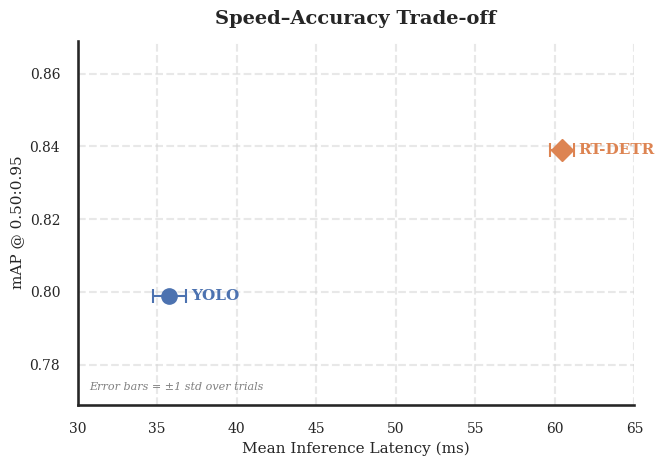

Saved optimized plot to scatter_speed_accuracy_clean_single_cat.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODE = "single_cat"

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "Times", "DejaVu Serif"],
})
sns.set_theme(style="white", context="talk", rc={
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "Times", "DejaVu Serif"],
})

df_perf  = pd.read_csv(f"performance_overall_{MODE}.csv")
df_speed = pd.read_csv(f"speed_{MODE}.csv")
df = pd.merge(df_perf, df_speed, on=["Model_Type", "Hardware"])

palette = sns.color_palette()
models  = df["Model_Type"].unique()
color_map  = {m: palette[i] for i, m in enumerate(models)}
MARKERS    = {"YOLO": "o", "RT-DETR": "D"}

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_title("Speed–Accuracy Trade-off", fontsize=14, fontweight="bold", pad=12)

# White dotted grid
ax.grid(True, linestyle="--", alpha=0.5, color="#d3d3d3", zorder=0)

for _, row in df.iterrows():
    model = row["Model_Type"]
    x     = row["Mean_Inf (ms)"]
    y     = row["mAP50-95"]
    std_x = row["Std_Inf (ms)"]
    color = color_map[model]

    ax.errorbar(
        x, y,
        xerr=std_x,
        fmt=MARKERS[model],
        color=color,
        markersize=11,
        capsize=5,
        capthick=1.5,
        elinewidth=1.5,
        zorder=3,
    )

    x_off = std_x + 0.3
    ax.annotate(
        model,
        xy=(x, y),
        xytext=(x + x_off, y),
        fontsize=11,
        fontweight="bold",
        color=color,
        va="center",
    )

# Axis labels
ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
ax.set_ylabel("mAP @ 0.50:0.95", fontsize=11)

# Dynamic axis limits for nice whitespace
x_vals = df["Mean_Inf (ms)"]
y_vals = df["mAP50-95"]
ax.set_xlim(30.0, 65.0)
ax.set_ylim(y_vals.min() - 0.03, min(y_vals.max() + 0.03, 1.0))

# Axis styling
ax.tick_params(labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

ax.annotate(
        "Error bars = ±1 std over trials",
        xy=(0.02, 0.04), xycoords="axes fraction",
        fontsize=8, color="gray", style="italic",
    )

plt.tight_layout()
out = f"scatter_speed_accuracy_clean_{MODE}.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved optimized plot to {out}")

In [9]:
import pandas as pd

perf  = pd.read_csv("../results/performance_overall_single_cat.csv")
speed = pd.read_csv("../results/speed_single_cat.csv")
# drop all columns that contain "Trial" in their name
speed = speed[[col for col in speed.columns if "Trial" not in col]]
# drop hardware column
speed = speed.drop(columns=["Hardware"])
# calculate \eta_{\text{inf}} = \frac{mAP@0.50{:}0.95}{\bar{t}_{\text{inf}}}
speed["eta_inf"] = perf["mAP50-95"] / speed["Total_Latency (ms)"]
speed.to_latex("../results/speed_single_cat.tex", index=False, float_format="%.2f")

In [7]:
import pandas as pd

speed = pd.read_csv("../results/performance_overall_multi_cat.csv")
# drop hardware column
speed = speed.drop(columns=["Hardware"])
speed.to_latex("../results/performance_overall_multi_cat.tex", index=False, float_format="%.2f")

In [ ]:
import pandas as pd
import numpy as np

def extract_training_times(model_name="Model"):
    perf  = pd.read_csv("../results/performance_overall_single_cat.csv")
    df = pd.read_csv(f"../results/training_results_{model_name}_single_cat.csv") 
    epoch_durations = df["time"].diff().fillna(df["time"].iloc[0])

    model_name_mapping = {
        "yolo": "YOLO",
        "detr": "RT-DETR"
    }
    model = model_name_mapping.get(model_name.lower(), model_name)
    
    total_time_seconds = df["time"].iloc[-1]
    mean_epoch_seconds = epoch_durations.mean()
    std_epoch_seconds = epoch_durations.std()
    
    def format_time(seconds):
        hours = int(seconds // 3600)
        minutes = int((seconds % 3600) // 60)
        secs = int(seconds % 60)
        if hours > 0:
            return f"{hours}h {minutes}m {secs}s"
        elif minutes > 0:
            return f"{minutes}m {secs}s"
        else:
            return f"{secs}s"

    # Summarize the results in a dictionary
    summary = {
        "Model": model,
        "Mean Epoch Time (s)": f"{mean_epoch_seconds:.2f}±{std_epoch_seconds:.2f}",
        "Total Training Time": format_time(total_time_seconds),
        "eta_train": f"{perf.loc[perf['Model_Type'] == model, 'mAP50-95'].values[0] / total_time_seconds:.4f}"
    }
    
    return pd.DataFrame([summary]), epoch_durations

summary_dfs = []
for model_name in ["yolo", "detr"]:
    df_summary, raw_durations = extract_training_times(model_name=model_name)

    print(f"\n=== TRAINING SUMMARY FOR {model_name.upper()} ===")
    print(df_summary.to_string(index=False))
    summary_dfs.append(df_summary)

# Combine all summaries into one DataFrame
final_summary_df = pd.concat(summary_dfs, ignore_index=True)
final_summary_df.to_latex("../results/training_summary.tex", index=False, float_format="%.2f")


=== TRAINING SUMMARY FOR YOLO ===
Model Mean Epoch Time (s) Total Training Time eta_train
 YOLO        286.55±12.59             47m 45s    0.0003

=== TRAINING SUMMARY FOR DETR ===
  Model Mean Epoch Time (s) Total Training Time eta_train
RT-DETR         393.72±4.82           1h 5m 37s    0.0002
